In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

In [25]:
maruti_df = pd.read_csv('brand_files/Maruti.csv')
hyundai_df = pd.read_csv('brand_files/Hyundai.csv')

print("Maruti shape:", maruti_df.shape)
print("Hyundai shape:", hyundai_df.shape)
print()
print(maruti_df.head())


Maruti shape: (1280, 8)
Hyundai shape: (821, 8)

                       name  year  selling_price  km_driven    fuel  \
0             Maruti 800 AC  2007          60000      70000  Petrol   
1  Maruti Wagon R LXI Minor  2007         135000      50000  Petrol   
2      Maruti Alto LX BSIII  2007         140000     125000  Petrol   
3  Maruti Celerio Green VXI  2017         365000      78000     CNG   
4             Maruti 800 AC  2007          60000      70000  Petrol   

  seller_type transmission        owner  
0  Individual       Manual  First Owner  
1  Individual       Manual  First Owner  
2  Individual       Manual  First Owner  
3  Individual       Manual  First Owner  
4  Individual       Manual  First Owner  


In [26]:
def prepare_data(df):
    df = df.copy()
    
    fuel_map = {'Petrol': 0, 'Diesel': 1, 'CNG': 2, 'LPG': 3}
    df['fuel'] = df['fuel'].map(fuel_map)
    
    seller_map = {'Individual': 0, 'Dealer': 1, 'Trustmark Dealer': 2}
    df['seller_type'] = df['seller_type'].map(seller_map)
    
    trans_map = {'Manual': 0, 'Automatic': 1}
    df['transmission'] = df['transmission'].map(trans_map)

    owner_map = {'First Owner': 0, 'Second Owner': 1, 'Third Owner': 2, 'Fourth & Above Owner': 3}
    df['owner'] = df['owner'].map(owner_map)
    
    df = df.drop('name', axis=1)
    
    return df

maruti_clean = prepare_data(maruti_df)
hyundai_clean = prepare_data(hyundai_df)

print("Done! Data is ready!")
print(maruti_clean.head())

Done! Data is ready!
   year  selling_price  km_driven  fuel  seller_type  transmission  owner
0  2007          60000      70000     0            0             0      0
1  2007         135000      50000     0            0             0      0
2  2007         140000     125000     0            0             0      0
3  2017         365000      78000     2            0             0      0
4  2007          60000      70000     0            0             0      0


In [27]:
X_maruti = maruti_clean.drop('selling_price', axis=1)
y_maruti = maruti_clean['selling_price']
X_maruti_train, X_maruti_test, y_maruti_train, y_maruti_test = train_test_split(X_maruti, y_maruti, test_size=0.2, random_state=42)

X_hyundai = hyundai_clean.drop('selling_price', axis=1)
y_hyundai = hyundai_clean['selling_price']
X_hyundai_train, X_hyundai_test, y_hyundai_train, y_hyundai_test = train_test_split(X_hyundai, y_hyundai, test_size=0.2, random_state=42)

print("Maruti training size:", X_maruti_train.shape)
print("Hyundai training size:", X_hyundai_train.shape)

Maruti training size: (1024, 6)
Hyundai training size: (656, 6)


In [28]:
lr_maruti = LinearRegression()
lr_maruti.fit(X_maruti_train, y_maruti_train)
lr_maruti_score = r2_score(y_maruti_test, lr_maruti.predict(X_maruti_test))

lr_hyundai = LinearRegression()
lr_hyundai.fit(X_hyundai_train, y_hyundai_train)
lr_hyundai_score = r2_score(y_hyundai_test, lr_hyundai.predict(X_hyundai_test))

print("Linear Regression Scores:")
print(f"Maruti  : {lr_maruti_score:.2f}")
print(f"Hyundai : {lr_hyundai_score:.2f}")

Linear Regression Scores:
Maruti  : 0.59
Hyundai : 0.53


In [29]:
rf_maruti = RandomForestRegressor(n_estimators=220, max_depth=8, min_samples_leaf=3, random_state=3)
rf_maruti.fit(X_maruti_train, y_maruti_train)
rf_maruti_score = r2_score(y_maruti_test, rf_maruti.predict(X_maruti_test))

rf_hyundai = RandomForestRegressor(n_estimators=220, max_depth=8, min_samples_leaf=3, random_state=3)
rf_hyundai.fit(X_hyundai_train, y_hyundai_train)
rf_hyundai_score = r2_score(y_hyundai_test, rf_hyundai.predict(X_hyundai_test))

print("Random Forest Scores:")
print(f"Maruti  : {rf_maruti_score:.2f}")
print(f"Hyundai : {rf_hyundai_score:.2f}")

Random Forest Scores:
Maruti  : 0.76
Hyundai : 0.66


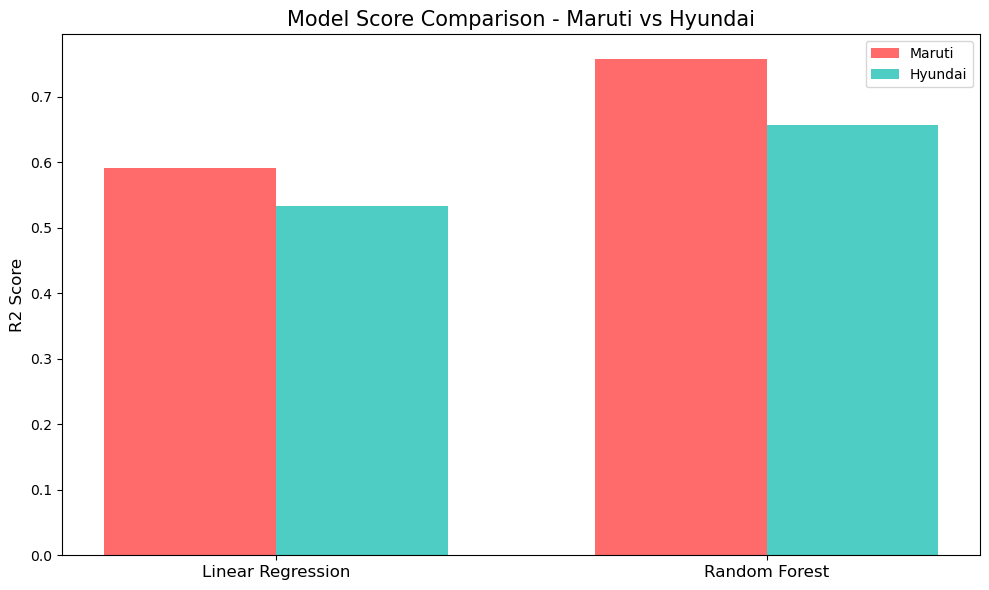

In [30]:
models = ['Linear Regression', 'Random Forest']
maruti_scores = [lr_maruti_score, rf_maruti_score]
hyundai_scores = [lr_hyundai_score, rf_hyundai_score]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, maruti_scores, width, label='Maruti', color='#FF6B6B')
plt.bar(x + width/2, hyundai_scores, width, label='Hyundai', color='#4ECDC4')

plt.title('Model Score Comparison - Maruti vs Hyundai', fontsize=15)
plt.ylabel('R2 Score', fontsize=12)
plt.xticks(x, models, fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()